# 04 - Modeling & Evaluation

Melatih tiga model klasifikasi: MultinomialNB (baseline), LinearSVC, dan RandomForest. Evaluasi lengkap dengan berbagai metrik, feature importance, dan hyperparameter tuning.

In [1]:
import re
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import sparse
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    matthews_corrcoef, precision_recall_curve, auc
)
from matplotlib.patches import Patch

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

def evaluate_model(name, y_test, y_pred, y_prob):
    print(f'=== {name} ===')
    print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
    print(f'F1 macro  : {f1_score(y_test, y_pred, average="macro"):.4f}')
    print(f'AUC-ROC   : {roc_auc_score(y_test, y_prob):.4f}')
    print(f'MCC       : {matthews_corrcoef(y_test, y_pred):.4f}')
    print(f'\nClassification Report:\n{classification_report(y_test, y_pred, target_names=["Fake", "True"])}')

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

## 1. Load Data

Data sudah di-split dan TF-IDF sudah di-fit hanya pada data training di notebook sebelumnya.

In [2]:
X_train = sparse.load_npz('../data/processed/X_train_tfidf.npz')
X_test = sparse.load_npz('../data/processed/X_test_tfidf.npz')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

print(f'Training: {X_train.shape[0]} data')
print(f'Testing : {X_test.shape[0]} data')
print(f'\nDistribusi train: {np.bincount(y_train)}')
print(f'Distribusi test : {np.bincount(y_test)}')

Training: 35751 data
Testing : 8938 data

Distribusi train: [18782 16969]
Distribusi test : [4696 4242]


## 2. Distribusi Data

In [3]:
print(f'Training: {X_train.shape[0]} data ({X_train.shape[1]} fitur)')
print(f'Testing : {X_test.shape[0]} data ({X_test.shape[1]} fitur)')
print(f'\nDistribusi train: {np.bincount(y_train)}')
print(f'Distribusi test : {np.bincount(y_test)}')

Training: 35751 data (50000 fitur)
Testing : 8938 data (50000 fitur)

Distribusi train: [18782 16969]
Distribusi test : [4696 4242]


## 3. Model Default

### 3.1 MultinomialNB (Baseline)

In [4]:
nb = MultinomialNB(alpha=1.0)
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:, 1]

evaluate_model('MultinomialNB', y_test, y_pred_nb, y_prob_nb)

=== MultinomialNB ===
Accuracy  : 0.9536
F1 macro  : 0.9535
AUC-ROC   : 0.9889
MCC       : 0.9069

Classification Report:
              precision    recall  f1-score   support

        Fake       0.96      0.95      0.96      4696
        True       0.95      0.95      0.95      4242

    accuracy                           0.95      8938
   macro avg       0.95      0.95      0.95      8938
weighted avg       0.95      0.95      0.95      8938



### 3.2 LinearSVC

In [5]:
svc = LinearSVC(max_iter=10000, random_state=43)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

svc_calibrated = CalibratedClassifierCV(svc, cv=5, method='sigmoid')
svc_calibrated.fit(X_train, y_train)
y_prob_svc = svc_calibrated.predict_proba(X_test)[:, 1]

evaluate_model('LinearSVC', y_test, y_pred_svc, y_prob_svc)

=== LinearSVC ===
Accuracy  : 0.9962
F1 macro  : 0.9962
AUC-ROC   : 0.9998
MCC       : 0.9924

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        True       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



### 3.3 RandomForest

In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=43, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

evaluate_model('RandomForest', y_test, y_pred_rf, y_prob_rf)

=== RandomForest ===
Accuracy  : 0.9874
F1 macro  : 0.9873
AUC-ROC   : 0.9990
MCC       : 0.9747

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        True       0.99      0.98      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



### 3.4 Perbandingan Model Default

In [7]:
default_results = {
    'MultinomialNB': {'y_pred': y_pred_nb, 'y_prob': y_prob_nb},
    'LinearSVC': {'y_pred': y_pred_svc, 'y_prob': y_prob_svc},
    'RandomForest': {'y_pred': y_pred_rf, 'y_prob': y_prob_rf}
}

print(f'{"Model":20s} {"Accuracy":>10s} {"F1 Macro":>10s} {"AUC-ROC":>10s} {"MCC":>10s}')
print('-' * 62)
for name, res in default_results.items():
    acc = accuracy_score(y_test, res['y_pred'])
    f1 = f1_score(y_test, res['y_pred'], average='macro')
    auc_roc = roc_auc_score(y_test, res['y_prob'])
    mcc = matthews_corrcoef(y_test, res['y_pred'])
    print(f'{name:20s} {acc:10.4f} {f1:10.4f} {auc_roc:10.4f} {mcc:10.4f}')

Model                  Accuracy   F1 Macro    AUC-ROC        MCC
--------------------------------------------------------------
MultinomialNB            0.9536     0.9535     0.9889     0.9069
LinearSVC                0.9962     0.9962     0.9998     0.9924
RandomForest             0.9874     0.9873     0.9990     0.9747


### 3.5 Cek Overfitting (Default Models)

Membandingkan performa model pada data training vs testing. Jika gap terlalu besar, model overfitting.

In [8]:
default_estimators = {'MultinomialNB': nb, 'LinearSVC': svc, 'RandomForest': rf}

print(f'{"Model":20s} {"Train Acc":>10s} {"Test Acc":>10s} {"Gap":>8s} {"Train F1":>10s} {"Test F1":>10s} {"Gap":>8s}')
print('-' * 78)
for name, model in default_estimators.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = default_results[name]['y_pred']
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    gap_acc = train_acc - test_acc
    gap_f1 = train_f1 - test_f1
    status = 'OK' if gap_acc < 0.05 else 'OVERFITTING'
    print(f'{name:20s} {train_acc:10.4f} {test_acc:10.4f} {gap_acc:8.4f} {train_f1:10.4f} {test_f1:10.4f} {gap_f1:8.4f}  {status}')

Model                 Train Acc   Test Acc      Gap   Train F1    Test F1      Gap
------------------------------------------------------------------------------
MultinomialNB            0.9582     0.9536   0.0047     0.9581     0.9535   0.0047  OK
LinearSVC                1.0000     0.9962   0.0038     1.0000     0.9962   0.0038  OK
RandomForest             1.0000     0.9874   0.0126     1.0000     0.9873   0.0127  OK


## 4. Visualisasi Model Default

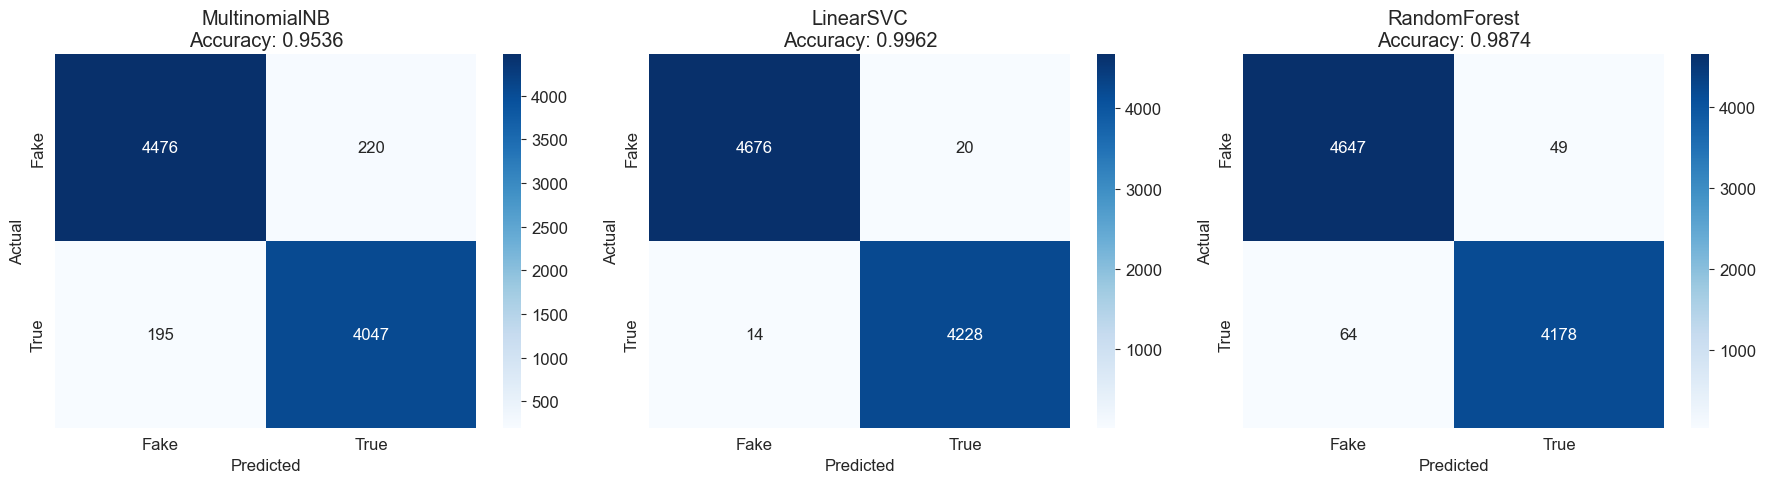

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, default_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'])
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, res["y_pred"]):.4f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('../images/05_confusion_matrix_default.png', dpi=150, bbox_inches='tight')
plt.show()

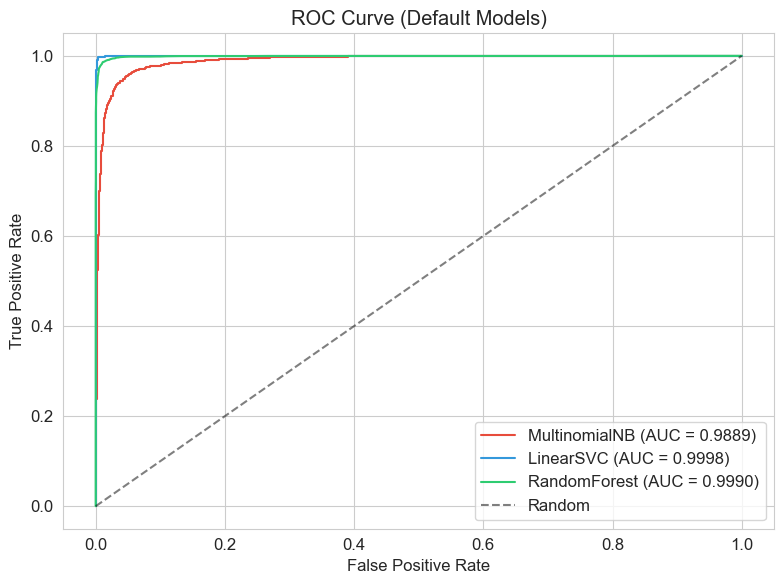

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71']
for (name, res), color in zip(default_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc_score = roc_auc_score(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, label=f'{name} (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (Default Models)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../images/06_roc_curve_default.png', dpi=150, bbox_inches='tight')
plt.show()

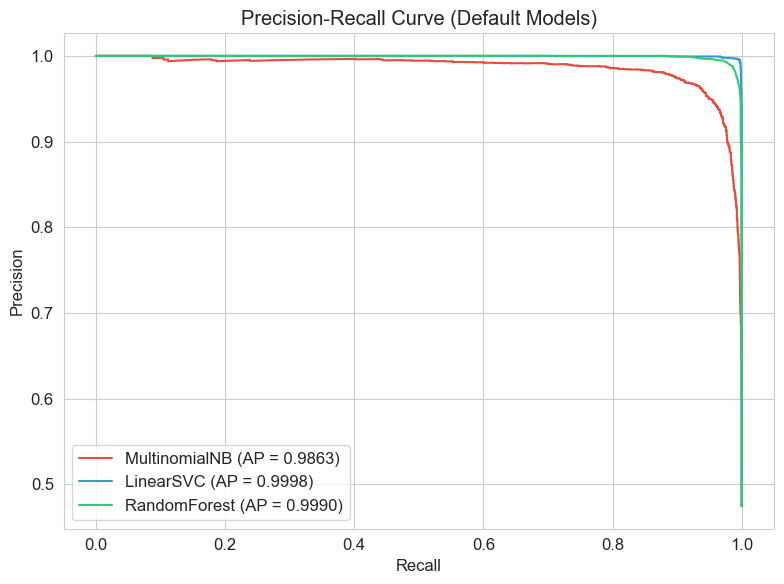

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
for (name, res), color in zip(default_results.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, res['y_prob'])
    pr_auc = auc(recall, precision)
    ax.plot(recall, precision, color=color, label=f'{name} (AP = {pr_auc:.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (Default Models)')
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig('../images/07_precision_recall_default.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Importance (Model Default Terbaik)

In [12]:
best_default_name = max(default_results.keys(),
                        key=lambda k: f1_score(y_test, default_results[k]['y_pred'], average='macro'))

best_default_estimators = {
    'MultinomialNB': nb,
    'LinearSVC': svc,
    'RandomForest': rf
}
best_default_model = best_default_estimators[best_default_name]

tfidf = joblib.load('../models/tfidf_vectorizer.pkl')
feature_names = tfidf.get_feature_names_out()

print(f'Model default terbaik: {best_default_name}')
print(f'F1 Macro: {f1_score(y_test, default_results[best_default_name]["y_pred"], average="macro"):.4f}')

Model default terbaik: LinearSVC
F1 Macro: 0.9962


In [13]:
if best_default_name == 'LinearSVC':
    coef = np.abs(best_default_model.coef_[0])
    top_idx = coef.argsort()[-20:][::-1]

    print(f'Top 20 Fitur ({best_default_name} - berdasarkan koefisien absolut):')
    print(f'{"Fitur":30s} {"Koefisien":>12s} {"Kelas dominan":>15s}')
    print('-' * 58)
    for idx in top_idx:
        kelas = 'True' if best_default_model.coef_[0][idx] > 0 else 'Fake'
        print(f'{feature_names[idx]:30s} {best_default_model.coef_[0][idx]:12.4f} {kelas:>15s}')

elif best_default_name == 'RandomForest':
    importances = best_default_model.feature_importances_
    top_idx = importances.argsort()[-20:][::-1]

    print(f'Top 20 Fitur ({best_default_name} - berdasarkan feature importance):')
    print(f'{"Fitur":30s} {"Importance":>12s}')
    print('-' * 44)
    for idx in top_idx:
        print(f'{feature_names[idx]:30s} {importances[idx]:12.4f}')

else:
    print(f'MultinomialNB tidak memiliki feature importance secara langsung.')
    print('Menampilkan top features dari coefficient MultinomialNB (log prob):')
    feature_log_prob = best_default_model.feature_log_prob_
    log_ratio = feature_log_prob[1] - feature_log_prob[0]
    top_idx = np.abs(log_ratio).argsort()[-20:][::-1]

    print(f'{"Fitur":30s} {"Log Ratio":>12s} {"Kelas dominan":>15s}')
    print('-' * 58)
    for idx in top_idx:
        kelas = 'True' if log_ratio[idx] > 0 else 'Fake'
        print(f'{feature_names[idx]:30s} {log_ratio[idx]:12.4f} {kelas:>15s}')

Top 20 Fitur (LinearSVC - berdasarkan koefisien absolut):
Fitur                             Koefisien   Kelas dominan
----------------------------------------------------------
said                                 5.7247            True
via                                 -5.2865            Fake
video                               -4.9691            Fake
said on                              3.6181            True
on tuesday                           3.2849            True
president trump                     -3.2567            Fake
on wednesday                         3.2527            True
us                                   3.2300            True
breaking                            -2.9302            Fake
on thursday                          2.7983            True
on friday                            2.7893            True
on                                   2.7704            True
obama                               -2.6507            Fake
us president                         2.6265

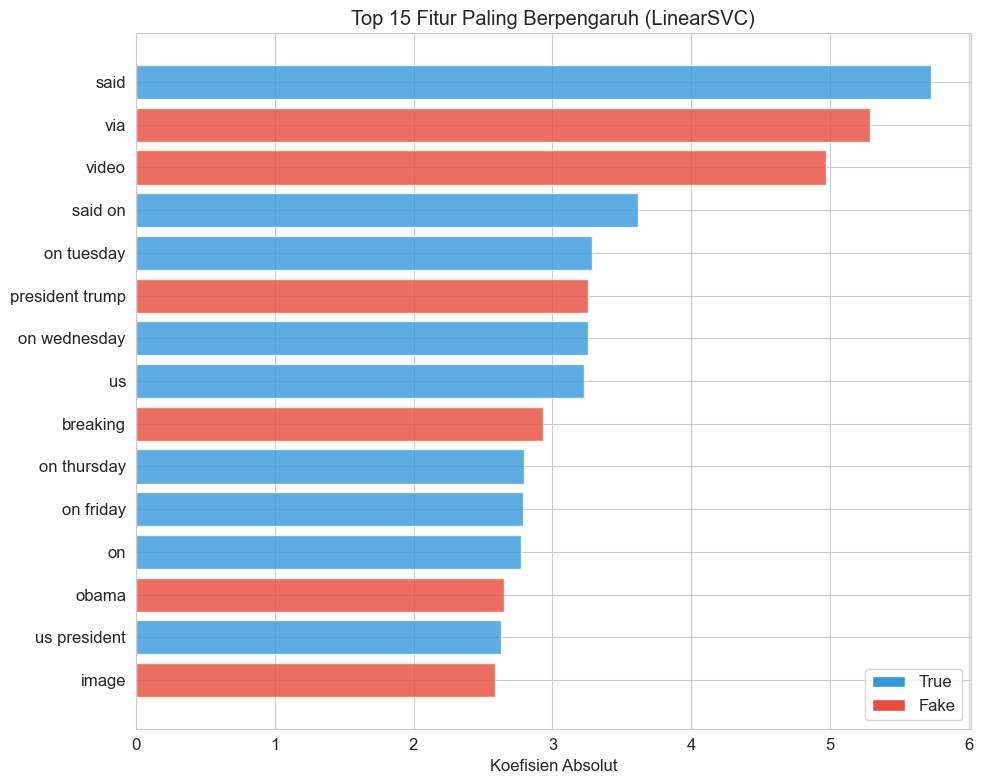

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 15

if best_default_name == 'LinearSVC':
    coef = best_default_model.coef_[0]
    top_idx = np.abs(coef).argsort()[-top_n:][::-1]
    top_features = [feature_names[i] for i in top_idx]
    top_coefs = [coef[i] for i in top_idx]
    bar_colors = ['#3498db' if c > 0 else '#e74c3c' for c in top_coefs]

    ax.barh(range(top_n), [abs(c) for c in top_coefs], color=bar_colors, alpha=0.8)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_features)
    ax.invert_yaxis()
    ax.set_xlabel('Koefisien Absolut')
    legend_elements = [Patch(facecolor='#3498db', label='True'),
                       Patch(facecolor='#e74c3c', label='Fake')]
    ax.legend(handles=legend_elements, loc='lower right')

elif best_default_name == 'RandomForest':
    importances = best_default_model.feature_importances_
    top_idx = importances.argsort()[-top_n:][::-1]
    ax.barh(range(top_n), importances[top_idx], color='#2ecc71', alpha=0.8)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_names[i] for i in top_idx])
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance')

else:
    log_ratio = best_default_model.feature_log_prob_[1] - best_default_model.feature_log_prob_[0]
    top_idx = np.abs(log_ratio).argsort()[-top_n:][::-1]
    top_features = [feature_names[i] for i in top_idx]
    top_vals = [log_ratio[i] for i in top_idx]
    bar_colors = ['#3498db' if v > 0 else '#e74c3c' for v in top_vals]

    ax.barh(range(top_n), [abs(v) for v in top_vals], color=bar_colors, alpha=0.8)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_features)
    ax.invert_yaxis()
    ax.set_xlabel('Log Probability Ratio')
    legend_elements = [Patch(facecolor='#3498db', label='True'),
                       Patch(facecolor='#e74c3c', label='Fake')]
    ax.legend(handles=legend_elements, loc='lower right')

ax.set_title(f'Top 15 Fitur Paling Berpengaruh ({best_default_name})')
plt.tight_layout()
plt.savefig('../images/08_feature_importance_default.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Hyperparameter Tuning

In [15]:
param_nb = {'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}
grid_nb = GridSearchCV(MultinomialNB(), param_nb, cv=5, scoring='f1_macro', n_jobs=-1)
grid_nb.fit(X_train, y_train)
print(f'MultinomialNB - Best params: {grid_nb.best_params_}, Best CV F1: {grid_nb.best_score_:.4f}')

MultinomialNB - Best params: {'alpha': 0.01}, Best CV F1: 0.9593


In [16]:
param_svc = {'C': [0.01, 0.1, 1.0, 10.0, 100.0]}
grid_svc = GridSearchCV(LinearSVC(max_iter=10000, random_state=43), param_svc, cv=5, scoring='f1_macro', n_jobs=-1)
grid_svc.fit(X_train, y_train)
print(f'LinearSVC - Best params: {grid_svc.best_params_}, Best CV F1: {grid_svc.best_score_:.4f}')

LinearSVC - Best params: {'C': 10.0}, Best CV F1: 0.9947


In [17]:
param_rf = {'n_estimators': [100, 200], 'max_depth': [None, 50, 100]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=43, n_jobs=-1), param_rf, cv=5, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print(f'RandomForest - Best params: {grid_rf.best_params_}, Best CV F1: {grid_rf.best_score_:.4f}')

RandomForest - Best params: {'max_depth': 100, 'n_estimators': 200}, Best CV F1: 0.9853


## 7. Evaluasi Model Tuned

In [18]:
nb_tuned = grid_nb.best_estimator_
y_pred_nb_t = nb_tuned.predict(X_test)
y_prob_nb_t = nb_tuned.predict_proba(X_test)[:, 1]
evaluate_model('MultinomialNB (Tuned)', y_test, y_pred_nb_t, y_prob_nb_t)

=== MultinomialNB (Tuned) ===
Accuracy  : 0.9573
F1 macro  : 0.9571
AUC-ROC   : 0.9909
MCC       : 0.9143

Classification Report:
              precision    recall  f1-score   support

        Fake       0.96      0.96      0.96      4696
        True       0.96      0.95      0.95      4242

    accuracy                           0.96      8938
   macro avg       0.96      0.96      0.96      8938
weighted avg       0.96      0.96      0.96      8938



In [19]:
svc_tuned = grid_svc.best_estimator_
y_pred_svc_t = svc_tuned.predict(X_test)

svc_tuned_calibrated = CalibratedClassifierCV(svc_tuned, cv=5)
svc_tuned_calibrated.fit(X_train, y_train)
y_prob_svc_t = svc_tuned_calibrated.predict_proba(X_test)[:, 1]

evaluate_model('LinearSVC (Tuned)', y_test, y_pred_svc_t, y_prob_svc_t)

=== LinearSVC (Tuned) ===
Accuracy  : 0.9960
F1 macro  : 0.9960
AUC-ROC   : 0.9998
MCC       : 0.9919

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        True       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



In [20]:
rf_tuned = grid_rf.best_estimator_
y_pred_rf_t = rf_tuned.predict(X_test)
y_prob_rf_t = rf_tuned.predict_proba(X_test)[:, 1]
evaluate_model('RandomForest (Tuned)', y_test, y_pred_rf_t, y_prob_rf_t)

=== RandomForest (Tuned) ===
Accuracy  : 0.9875
F1 macro  : 0.9874
AUC-ROC   : 0.9991
MCC       : 0.9749

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        True       0.99      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



### 7.1 Cek Overfitting (Tuned Models)

Membandingkan performa model tuned pada data training vs testing.

In [21]:
tuned_estimators = {
    'MultinomialNB (Tuned)': nb_tuned,
    'LinearSVC (Tuned)': svc_tuned,
    'RandomForest (Tuned)': rf_tuned
}

print(f'{"Model":30s} {"Train Acc":>10s} {"Test Acc":>10s} {"Gap":>8s} {"Train F1":>10s} {"Test F1":>10s} {"Gap":>8s}')
print('-' * 88)
for name, model in tuned_estimators.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    gap_acc = train_acc - test_acc
    gap_f1 = train_f1 - test_f1
    status = 'OK' if gap_acc < 0.05 else 'OVERFITTING'
    print(f'{name:30s} {train_acc:10.4f} {test_acc:10.4f} {gap_acc:8.4f} {train_f1:10.4f} {test_f1:10.4f} {gap_f1:8.4f}  {status}')

Model                           Train Acc   Test Acc      Gap   Train F1    Test F1      Gap
----------------------------------------------------------------------------------------
MultinomialNB (Tuned)              0.9640     0.9573   0.0067     0.9639     0.9571   0.0067  OK
LinearSVC (Tuned)                  1.0000     0.9960   0.0040     1.0000     0.9960   0.0040  OK
RandomForest (Tuned)               1.0000     0.9875   0.0125     1.0000     0.9874   0.0125  OK


## 8. Perbandingan: Default vs Tuned

In [22]:
all_models = {
    'MultinomialNB': {'y_pred': y_pred_nb, 'y_prob': y_prob_nb},
    'MultinomialNB (Tuned)': {'y_pred': y_pred_nb_t, 'y_prob': y_prob_nb_t},
    'LinearSVC': {'y_pred': y_pred_svc, 'y_prob': y_prob_svc},
    'LinearSVC (Tuned)': {'y_pred': y_pred_svc_t, 'y_prob': y_prob_svc_t},
    'RandomForest': {'y_pred': y_pred_rf, 'y_prob': y_prob_rf},
    'RandomForest (Tuned)': {'y_pred': y_pred_rf_t, 'y_prob': y_prob_rf_t}
}

print(f'{"Model":30s} {"Accuracy":>10s} {"F1 Macro":>10s} {"AUC-ROC":>10s} {"MCC":>10s}')
print('-' * 72)
for name, res in all_models.items():
    acc = accuracy_score(y_test, res['y_pred'])
    f1 = f1_score(y_test, res['y_pred'], average='macro')
    auc_roc = roc_auc_score(y_test, res['y_prob'])
    mcc = matthews_corrcoef(y_test, res['y_pred'])
    print(f'{name:30s} {acc:10.4f} {f1:10.4f} {auc_roc:10.4f} {mcc:10.4f}')

Model                            Accuracy   F1 Macro    AUC-ROC        MCC
------------------------------------------------------------------------
MultinomialNB                      0.9536     0.9535     0.9889     0.9069
MultinomialNB (Tuned)              0.9573     0.9571     0.9909     0.9143
LinearSVC                          0.9962     0.9962     0.9998     0.9924
LinearSVC (Tuned)                  0.9960     0.9960     0.9998     0.9919
RandomForest                       0.9874     0.9873     0.9990     0.9747
RandomForest (Tuned)               0.9875     0.9874     0.9991     0.9749


## 9. Pilih Model Terbaik & Cek Feature Importance

In [23]:
best_name = max(all_models.keys(),
                key=lambda k: f1_score(y_test, all_models[k]['y_pred'], average='macro'))
best_predictions = all_models[best_name]['y_pred']

print(f'Model terbaik: {best_name}')
print(f'F1 Macro: {f1_score(y_test, all_models[best_name]["y_pred"], average="macro"):.4f}')

Model terbaik: LinearSVC
F1 Macro: 0.9962


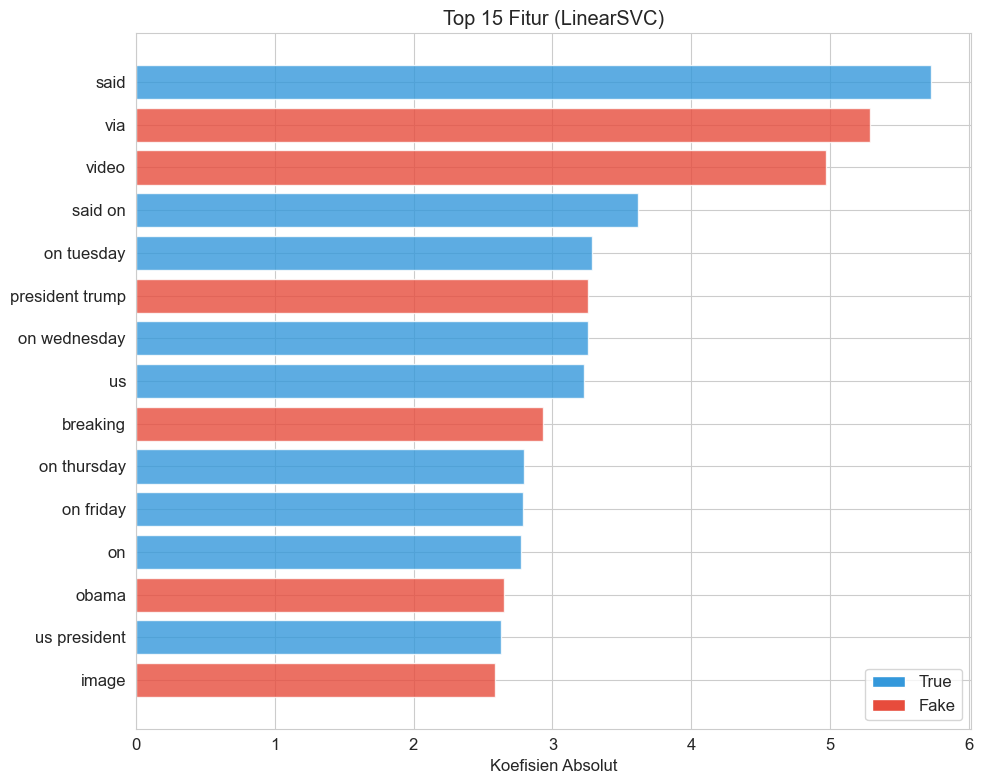

In [24]:
best_estimator_map = {
    'MultinomialNB': nb,
    'MultinomialNB (Tuned)': nb_tuned,
    'LinearSVC': svc,
    'LinearSVC (Tuned)': svc_tuned,
    'RandomForest': rf,
    'RandomForest (Tuned)': rf_tuned
}
best_estimator_model = best_estimator_map[best_name]

if 'LinearSVC' in best_name:
    coef = np.abs(best_estimator_model.coef_[0])
    top_idx = coef.argsort()[-15:][::-1]

    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = [feature_names[i] for i in top_idx]
    top_coefs = [best_estimator_model.coef_[0][i] for i in top_idx]
    bar_colors = ['#3498db' if c > 0 else '#e74c3c' for c in top_coefs]

    ax.barh(range(15), [abs(c) for c in top_coefs], color=bar_colors, alpha=0.8)
    ax.set_yticks(range(15))
    ax.set_yticklabels(top_features)
    ax.invert_yaxis()
    ax.set_xlabel('Koefisien Absolut')
    legend_elements = [Patch(facecolor='#3498db', label='True'),
                       Patch(facecolor='#e74c3c', label='Fake')]
    ax.legend(handles=legend_elements, loc='lower right')

elif 'RandomForest' in best_name:
    importances = best_estimator_model.feature_importances_
    top_idx = importances.argsort()[-15:][::-1]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(15), importances[top_idx], color='#2ecc71', alpha=0.8)
    ax.set_yticks(range(15))
    ax.set_yticklabels([feature_names[i] for i in top_idx])
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance')

else:
    log_ratio = best_estimator_model.feature_log_prob_[1] - best_estimator_model.feature_log_prob_[0]
    top_idx = np.abs(log_ratio).argsort()[-15:][::-1]

    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = [feature_names[i] for i in top_idx]
    top_vals = [log_ratio[i] for i in top_idx]
    bar_colors = ['#3498db' if v > 0 else '#e74c3c' for v in top_vals]

    ax.barh(range(15), [abs(v) for v in top_vals], color=bar_colors, alpha=0.8)
    ax.set_yticks(range(15))
    ax.set_yticklabels(top_features)
    ax.invert_yaxis()
    ax.set_xlabel('Log Probability Ratio')
    legend_elements = [Patch(facecolor='#3498db', label='True'),
                       Patch(facecolor='#e74c3c', label='Fake')]
    ax.legend(handles=legend_elements, loc='lower right')

ax.set_title(f'Top 15 Fitur ({best_name})')
plt.tight_layout()
plt.savefig('../images/09_feature_importance_best.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Simpan Model Terbaik

In [25]:
model_to_save = best_estimator_map[best_name]
joblib.dump(model_to_save, '../models/model_best.pkl')

print(f'Model terbaik: {best_name}')
print(f'Tersimpan ke: models/model_best.pkl')

Model terbaik: LinearSVC
Tersimpan ke: models/model_best.pkl


## 11. Coba Prediksi

In [26]:
tfidf = joblib.load('../models/tfidf_vectorizer.pkl')

test_texts = [
    "WASHINGTON The president signed a new executive order on trade policy today",
    "You wont believe what this celebrity did at the award show last night",
    "Federal Reserve announces interest rate decision amid economic uncertainty",
    "BREAKING exposed the shocking truth about the government"
]

test_clean = [preprocess(t) for t in test_texts]
test_tfidf = tfidf.transform(test_clean)
predictions = model_to_save.predict(test_tfidf)
labels = ['Fake' if p == 0 else 'True' for p in predictions]

for text, label in zip(test_texts, labels):
    print(f'[{label:4s}] {text[:80]}...')

[Fake] WASHINGTON The president signed a new executive order on trade policy today...
[Fake] You wont believe what this celebrity did at the award show last night...
[Fake] Federal Reserve announces interest rate decision amid economic uncertainty...
[Fake] BREAKING exposed the shocking truth about the government...
